# 07 비디오 키포인트 탐지 — 특징점 · 인체 포즈 · 시간축 추적

**06 OCR**에서 텍스트 좌표를 다뤘다면, 이번에는 영상 프레임에서 **키포인트(관심점 좌표)** 를 찾고 **프레임 간 추적**합니다. 산업 현장에서는 **설비 특징점(ORB)** 으로 움직임을 보고, **작업자 포즈(COCO 17점)** 로 자세·접근 여부를 분석할 수 있습니다.

| Part | 주제 |
|------|------|
| 1 | IPAD 프레임 준비 · 키포인트 개념 · 샘플 이미지 |
| 2 | **특징점 검출** — Harris · ORB (OpenCV 베이스라인) |
| 3 | **인체 포즈** — torchvision Keypoint R-CNN (pretrained) |
| 4 | 적응형 추적 · motion z-score · 밀도맵 · manifest |
| 5 | 포즈 시간 안정성 — 관절 각도 변화 (인물 있을 때) |

### 키포인트 탐지란?

**키포인트(Keypoint)** 는 이미지·영상에서 **의미 있는 좌표 (x, y)** 입니다. 종류에 따라 역할이 다릅니다.

```
프레임
    ↓ 특징점 (ORB/Harris) — "이 코너·텍스처 점을 프레임마다 추적"
    ↓ 구조 키포인트 (Pose)   — "어깨·팔꿈치·무릎 등 17개 관절"
    ↓ 시간축                 — 연속 프레임에서 이동량·자세 변화
```

02번 **Motion** · 04번 **이상 탐지**와 연결: 키포인트 **이동량(displacement)** 이 크면 설비·작업 동작 변화 신호가 됩니다.

### IPAD 실습 데이터 (선택)

1. 노트북과 **같은 폴더**에 `IPAD_sample.zip` 배치 (05·06과 동일)
2. 실행 시 자동 압축 해제 → `IPAD_Sample/`
3. zip 없어도 **합성 패턴 + 포즈 샘플 이미지**로 Part 1~4 실행 가능

> **설치:** `requirements.txt`에 포함된 `torch`, `torchvision`, `opencv-python`만으로 실행됩니다. (별도 학습 없음)


### 본 실습에서 다루는 기술

| 기법 | 한 줄 설명 | 코드에서의 역할 |
|------|-----------|----------------|
| **Harris Corner** | 밝기 변화가 큰 코너 검출 | `detect_harris_corners` |
| **ORB** | 회전·스케일에 강한 특징점+기술자 | `detect_orb_keypoints` |
| **LK Optical Flow** | 프레임 간 특징점 추적 | `track_keypoints_lk` |
| **Keypoint R-CNN** | COCO 17 관절 포즈 (pretrained) | `get_pose_model`, `detect_human_pose` |
| **Displacement** | 키포인트 평균 이동량 | `compute_keypoint_displacement` |
| **Keypoint Pipeline** | 검출→추적→JSON | `run_keypoint_pipeline`, `export_keypoint_manifest` |
| **Video Frame** | IPAD 클립 연속 프레임 | `load_ipad_clip_frames` (선택) |
| **Shi-Tomasi** | 코너 품질 기반 검출 | `detect_shi_tomasi_corners` |
| **RANSAC Homography** | 매칭 inlier·변환 추정 | `estimate_homography_ransac` |
| **Motion Z-score** | displacement 이상 신호 | `compute_displacement_zscore` |
| **Pose Angles** | 관절 각도(인체공학) | `compute_pose_angles` |
| **Density Heatmap** | 키포인트 누적 밀도 | `build_keypoint_density_map` |
| **Pose Temporal** | 프레임 간 각도 변화 | `analyze_pose_temporal_stability` |

핵심: 영상 키포인트는 **프레임 단위 좌표 검출**을 **시간축에 쌓아** 동작·이상 신호로 쓰는 것입니다.

#### 용어·기술 상세 (쉬운 설명)

| 용어 | 쉬운 설명 |
|------|-----------|
| **Feature Keypoint** | 코너·돌출부 등 **다시 찾기 쉬운 점** — 설비 부품·마크 추적에 사용 |
| **Descriptor** | 키포인트 주변 **패턴 지문** — ORB가 프레임 간 같은 점을 매칭할 때 사용 |
| **Pose Keypoint** | 사람 **관절 좌표** (코, 어깨, 무릎 등 17개) |
| **Skeleton** | 관절을 **뼈대 선**으로 연결한 시각화 |
| **Optical Flow** | 이전→다음 프레임에서 **같은 점이 어디로 갔는지** 추정 |
| **Displacement** | 추적된 점들의 **평균 이동 거리** — 02번 motion 점수와 유사한 역할 |
| **pretrained** | COCO로 **이미 학습된** Keypoint R-CNN weight 사용 (우리는 학습 안 함) |
| **manifest** | 프레임별 키포인트 결과 JSON — 08번 통합 manifest 입력 |


In [1]:
# ── 패키지 설치 (최초 1회, 주석 해제 후 실행) ──
# !pip install -q -r requirements.txt


In [2]:
from __future__ import annotations

# =============================================================================
# 환경 설정 — import, IPAD/출력 경로, 키포인트 하이퍼파라미터, 한글 폰트
# =============================================================================

import json
import os
import platform
import subprocess
import urllib.request
import zipfile
from dataclasses import dataclass, field
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision
from matplotlib.gridspec import GridSpec
from scipy.ndimage import gaussian_filter
from torchvision.models.detection import keypointrcnn_resnet50_fpn
from torchvision.transforms import functional as TF

# ── 입력 데이터(IPAD) 설정 ─────────────────────────────────────────────────────
# IPAD_sample.zip을 노트북 폴더에 두면 자동으로 찾아서 풀고 프레임을 로드합니다.
# (05/06 노트북과 동일한 zip 이름 규칙을 따릅니다.)
IPAD_ZIP_NAMES = ("IPAD_sample.zip", "IPAD_Sample.zip")
# 압축 해제 후 탐색할 후보 폴더 이름(상대경로)
IPAD_SEARCH_PATHS = [Path("IPAD_Sample"), Path("IPAD_sample")]
# 프레임으로 인정할 이미지 확장자(대소문자 무시)
FRAME_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

# ── 출력 경로 ─────────────────────────────────────────────────────────────────
# figures: 보고서용 그래프 / predictions: 오버레이 이미지 / manifest: JSON 결과
OUTPUT_DIR = Path("output_keypoint")
FIG_DIR = OUTPUT_DIR / "figures"
PRED_DIR = OUTPUT_DIR / "predictions"
MANIFEST_PATH = OUTPUT_DIR / "keypoint_manifest.json"
SAMPLE_DIR = OUTPUT_DIR / "samples"

# ── 특징점(설비/부품) 파라미터 ───────────────────────────────────────────────
# ORB_MAX_FEATURES: 한 프레임에서 최대 몇 개의 ORB 특징점을 뽑을지
# ORB_MATCH_RATIO: Lowe ratio test 임계값(낮을수록 더 엄격)
ORB_MAX_FEATURES = 500
ORB_MATCH_RATIO = 0.75
# 코너 검출 수 (Harris/ Shi-Tomasi)
HARRIS_MAX_CORNERS = 120
SHITOMASI_MAX_CORNERS = 150
SHITOMASI_QUALITY = 0.02
SHITOMASI_MIN_DISTANCE = 6
# RANSAC 기하 정합에서 허용하는 재투영 오차(픽셀)
RANSAC_REPROJ_THRESH = 5.0

# ── 포즈(사람) 파라미터 ───────────────────────────────────────────────────────
# POSE_SCORE_THRESH: 사람 검출 confidence 임계값
# POSE_KPT_VIS_THRESH: 각 관절(키포인트)의 visibility 임계값
POSE_SCORE_THRESH = 0.7
POSE_KPT_VIS_THRESH = 0.3
# 포즈 데모는 인물 샘플 이미지를 사용(학습 없이 pretrained 모델만 실행)
POSE_SAMPLE_URL = "https://ultralytics.com/images/zidane.jpg"
POSE_SAMPLE_PATH = SAMPLE_DIR / "pose_sample.jpg"
# IPAD 프레임에 인물이 있을 때 포즈도 시도(설비만 있으면 0명이 정상)
RUN_IPAD_POSE = True

# ── 비디오(프레임 시퀀스) 파라미터 ──────────────────────────────────────────
# MAX_IPAD_FRAMES: 실습 속도를 위해 일부 프레임만 사용
# IPAD_FRAME_STRIDE: N프레임마다 샘플링(값이 작을수록 더 촘촘)
MAX_IPAD_FRAMES = 24
IPAD_FRAME_STRIDE = 3
# 추적용 ORB 특징점 상한(너무 크면 LK가 느려짐)
PIPELINE_ORB_FEATURES = 200
# LK optical flow 파라미터(창 크기/피라미드 레벨)
LK_WIN_SIZE = (21, 21)
LK_MAX_LEVEL = 3
# 추적 가능한 점이 너무 적으면 ORB 재검출로 상태를 리셋
MIN_TRACKED_POINTS = 25
# displacement의 z-score가 이 값 이상이면 "움직임 급변" 후보로 표시
DISPLACEMENT_Z_THRESHOLD = 2.0
# 누적 밀도맵 smoothing(픽셀). 클수록 더 부드러워짐
HEATMAP_GAUSSIAN_SIGMA = 18.0

# ── 실행 장치 ─────────────────────────────────────────────────────────────────
# GPU가 있으면 cuda, 없으면 cpu로 실행 (torchvision Keypoint R-CNN 포함)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 결과 폴더는 미리 생성(Windows 한글 경로에서도 안전하게 저장하기 위함)
for d in (OUTPUT_DIR, FIG_DIR, PRED_DIR, SAMPLE_DIR):
    d.mkdir(parents=True, exist_ok=True)


def is_running_in_colab() -> bool:
    try:
        import google.colab  # noqa: F401
        return True
    except ImportError:
        return False


def setup_matplotlib_korean() -> None:
    from matplotlib import font_manager
    if is_running_in_colab():
        subprocess.run(
            ["apt-get", "-qq", "-y", "install", "fonts-nanum"],
            check=False, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL,
        )
        font_manager._load_fontmanager(try_read_cache=False)
    if platform.system() == "Windows":
        candidates = ["Malgun Gothic", "NanumGothic", "Gulim"]
        fallback = Path(os.environ.get("WINDIR", r"C:\Windows")) / "Fonts" / "malgun.ttf"
    elif platform.system() == "Darwin":
        candidates = ["AppleGothic", "Apple SD Gothic Neo"]
        fallback = None
    else:
        candidates = ["NanumGothic", "NanumBarunGothic"]
        fallback = Path("/usr/share/fonts/truetype/nanum/NanumGothic.ttf")
    available = {f.name for f in font_manager.fontManager.ttflist}
    chosen = next((n for n in candidates if n in available), None)
    if chosen:
        plt.rcParams["font.family"] = chosen
    elif fallback and fallback.exists():
        font_manager.fontManager.addfont(str(fallback))
        plt.rcParams["font.family"] = font_manager.FontProperties(fname=str(fallback)).get_name()
    plt.rcParams["axes.unicode_minus"] = False


COCO_KEYPOINT_NAMES = [
    "nose", "left_eye", "right_eye", "left_ear", "right_ear",
    "left_shoulder", "right_shoulder", "left_elbow", "right_elbow",
    "left_wrist", "right_wrist", "left_hip", "right_hip",
    "left_knee", "right_knee", "left_ankle", "right_ankle",
]
COCO_SKELETON = [
    (5, 6), (5, 7), (7, 9), (6, 8), (8, 10),
    (5, 11), (6, 12), (11, 12), (11, 13), (13, 15),
    (12, 14), (14, 16), (0, 1), (0, 2), (1, 3), (2, 4), (0, 5), (0, 6),
]
POSE_ANGLE_TRIPLETS = {
    "left_elbow": (5, 7, 9),
    "right_elbow": (6, 8, 10),
    "left_shoulder": (7, 5, 11),
    "right_shoulder": (8, 6, 12),
    "left_knee": (11, 13, 15),
    "right_knee": (12, 14, 16),
    "left_hip": (5, 11, 13),
    "right_hip": (6, 12, 14),
}


@dataclass
class KeypointResult:
    image_path: str
    method: str
    feature_points: list[list[float]] = field(default_factory=list)
    pose_persons: list[dict] = field(default_factory=list)
    displacement: float | None = None
    motion_z: float | None = None
    meta: dict = field(default_factory=dict)


@dataclass
class TrackingState:
    points: np.ndarray
    descriptors: np.ndarray | None = None


def read_image_bgr(path: Path) -> np.ndarray:
    buf = np.fromfile(str(path), dtype=np.uint8)
    img = cv2.imdecode(buf, cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(f"이미지 로드 실패: {path}")
    return img


def bgr_to_rgb(img_bgr: np.ndarray) -> np.ndarray:
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)


setup_matplotlib_korean()
print(f"환경 설정 완료 | device={DEVICE} | torchvision={torchvision.__version__}")


환경 설정 완료 | device=cuda | torchvision=0.26.0+cu126


In [3]:
# =============================================================================
# IPAD 로드 · 샘플 이미지 · 공통 시각화 · 기하 유틸
# =============================================================================

def _search_roots() -> list[Path]:
    """데이터/zip 탐색을 위한 루트 디렉토리 후보 목록.

    - 기본: 현재 작업 디렉토리(Path.cwd)
    - 추가: Cursor/VSCode 노트북 경로(__vsc_ipynb_file__)의 폴더

    노트북을 다른 위치에서 실행해도 zip을 잘 찾도록 하기 위한 유틸입니다.
    """
    roots: list[Path] = [Path.cwd().resolve()]
    try:
        from IPython import get_ipython

        ip = get_ipython()
        # Cursor/VSCode에서 노트북 파일 경로가 여기에 들어오는 경우가 많습니다.
        nb_file = ip.user_ns.get("__vsc_ipynb_file__") if ip else None
        if nb_file:
            nb_dir = Path(nb_file).resolve().parent
            if nb_dir not in roots:
                # 노트북이 있는 폴더를 우선순위 1순위로 둡니다.
                roots.insert(0, nb_dir)
    except Exception:
        # IPython이 아니거나 변수 접근이 실패해도 전체 파이프라인은 정상 동작해야 합니다.
        pass
    return roots


def _list_frame_files(frame_dir: Path) -> list[Path]:
    """클립 폴더에서 프레임 이미지 파일을 정렬해 반환."""
    files = [p for p in frame_dir.iterdir() if p.suffix.lower() in FRAME_EXTS]
    # 파일명 정렬이 프레임 순서(000.jpg, 001.jpg, ...)에 대응한다고 가정합니다.
    return sorted(files, key=lambda p: p.name)


def find_ipad_zip() -> Path | None:
    """노트북 폴더/현재 폴더에서 IPAD_sample.zip을 찾습니다.

    - IPAD_ZIP_NAMES에 정의된 이름 우선
    - 그 외에도 stem이 ipad_sample인 zip을 허용(대소문자/변형 대응)
    """
    for root in _search_roots():
        for name in IPAD_ZIP_NAMES:
            p = root / name
            if p.is_file():
                return p
        try:
            for f in root.iterdir():
                if f.is_file() and f.suffix.lower() == ".zip" and f.stem.lower() == "ipad_sample":
                    return f
        except OSError:
            # 권한/네트워크 경로 등으로 iterdir가 실패할 수 있으므로 방어적으로 무시
            continue
    return None


def ensure_ipad_sample() -> Path | None:
    for root in _search_roots():
        for rel in IPAD_SEARCH_PATHS:
            base = root / rel
            if base.is_dir():
                frames = list(base.rglob("*"))
                if any(p.suffix.lower() in FRAME_EXTS for p in frames if p.is_file()):
                    return base
    zpath = find_ipad_zip()
    if zpath is None:
        return None
    extract_to = zpath.parent
    print(f"[IPAD] {zpath.name} 압축 해제 중 -> {extract_to.resolve()}")
    with zipfile.ZipFile(zpath, "r") as zf:
        zf.extractall(extract_to)
    for rel in IPAD_SEARCH_PATHS:
        base = extract_to / rel
        if base.is_dir():
            return base
    return extract_to / IPAD_SEARCH_PATHS[0] if (extract_to / IPAD_SEARCH_PATHS[0]).is_dir() else None


def load_ipad_clip_frames(max_frames: int = MAX_IPAD_FRAMES, stride: int = IPAD_FRAME_STRIDE) -> list[Path]:
    root = ensure_ipad_sample()
    if root is None:
        return []
    candidates: list[Path] = []
    for split in ("testing", "training"):
        for frames_root in root.rglob("frames"):
            if split not in str(frames_root):
                continue
            for clip_dir in sorted(frames_root.iterdir()):
                if clip_dir.is_dir():
                    candidates.extend(_list_frame_files(clip_dir))
                    if candidates:
                        break
            if candidates:
                break
        if candidates:
            break
    if not candidates:
        candidates = sorted(p for p in root.rglob("*") if p.suffix.lower() in FRAME_EXTS)
    return candidates[::max(1, stride)][:max_frames]


def make_checkerboard_pattern(size: int = 480, cells: int = 8) -> np.ndarray:
    cell = size // cells
    board = np.zeros((size, size), dtype=np.uint8)
    for i in range(cells):
        for j in range(cells):
            if (i + j) % 2 == 0:
                board[i * cell:(i + 1) * cell, j * cell:(j + 1) * cell] = 220
    img = cv2.cvtColor(board, cv2.COLOR_GRAY2BGR)
    cv2.circle(img, (size // 3, size // 3), 40, (0, 120, 255), 3)
    cv2.rectangle(img, (size // 2, size // 4), (3 * size // 4, 3 * size // 4), (0, 200, 0), 3)
    return img


def ensure_pose_sample_image() -> Path:
    if POSE_SAMPLE_PATH.is_file():
        return POSE_SAMPLE_PATH
    try:
        print(f"[Pose] 샘플 이미지 다운로드: {POSE_SAMPLE_URL}")
        urllib.request.urlretrieve(POSE_SAMPLE_URL, POSE_SAMPLE_PATH)
        return POSE_SAMPLE_PATH
    except Exception as exc:
        print(f"[Pose] 다운로드 실패 ({exc}) — 합성 패턴으로 대체")
        img = make_checkerboard_pattern()
        cv2.imencode(".jpg", img)[1].tofile(str(POSE_SAMPLE_PATH))
        return POSE_SAMPLE_PATH


def angle_between_points(a: np.ndarray, b: np.ndarray, c: np.ndarray) -> float:
    """∠ABC 각도(도). b가 꼭짓점."""
    ba = a - b
    bc = c - b
    denom = np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-6
    cosang = float(np.clip(np.dot(ba, bc) / denom, -1.0, 1.0))
    return float(np.degrees(np.arccos(cosang)))


def draw_feature_keypoints(image_bgr: np.ndarray, points: np.ndarray, color=(0, 255, 255), radius: int = 3) -> np.ndarray:
    vis = image_bgr.copy()
    for pt in points:
        x, y = int(round(pt[0])), int(round(pt[1]))
        cv2.circle(vis, (x, y), radius, color, -1)
    return vis


def draw_motion_vectors(image_bgr: np.ndarray, prev_pts: np.ndarray, next_pts: np.ndarray, step: int = 4) -> np.ndarray:
    vis = image_bgr.copy()
    for p0, p1 in zip(prev_pts[::step], next_pts[::step]):
        x0, y0 = int(p0[0]), int(p0[1])
        x1, y1 = int(p1[0]), int(p1[1])
        cv2.arrowedLine(vis, (x0, y0), (x1, y1), (0, 255, 128), 1, tipLength=0.35)
    return vis


def build_keypoint_density_map(points_list: list[np.ndarray], shape: tuple[int, int]) -> np.ndarray:
    h, w = shape
    acc = np.zeros((h, w), dtype=np.float32)
    for pts in points_list:
        for x, y in pts:
            xi, yi = int(round(x)), int(round(y))
            if 0 <= xi < w and 0 <= yi < h:
                acc[yi, xi] += 1.0
    if acc.max() > 0:
        acc = gaussian_filter(acc, sigma=HEATMAP_GAUSSIAN_SIGMA)
        acc = acc / acc.max()
    return acc


def draw_pose_skeleton(image_bgr: np.ndarray, keypoints: np.ndarray, scores: np.ndarray) -> np.ndarray:
    vis = image_bgr.copy()
    kpts = keypoints.reshape(-1, 2)
    sc = scores.reshape(-1)
    for i, j in COCO_SKELETON:
        if sc[i] > POSE_KPT_VIS_THRESH and sc[j] > POSE_KPT_VIS_THRESH:
            p1 = tuple(int(v) for v in kpts[i])
            p2 = tuple(int(v) for v in kpts[j])
            cv2.line(vis, p1, p2, (255, 128, 0), 2, cv2.LINE_AA)
    for idx, (x, y) in enumerate(kpts):
        if sc[idx] > POSE_KPT_VIS_THRESH:
            cv2.circle(vis, (int(x), int(y)), 4, (0, 255, 0), -1)
    return vis


## Part 1 — IPAD 프레임 · 키포인트 개념

| 용어 | 설명 |
|------|------|
| **Feature KP** | 코너·텍스처 — ORB/Harris |
| **Pose KP** | 사람 관절 17점 — Keypoint R-CNN |
| **Tracking** | 연속 프레임에서 같은 점 따라가기 |

> **한 줄 요약:** IPAD 설비 프레임(또는 합성 패턴)으로 키포인트 실습 입력을 준비합니다.


[IPAD] IPAD_sample.zip 압축 해제 중 -> C:\MyCursorLab\08_Video AI 처리 및 분석
[Pose] 샘플 이미지 다운로드: https://ultralytics.com/images/zidane.jpg
[IPAD] 프레임 24장 | 예: 000.jpg


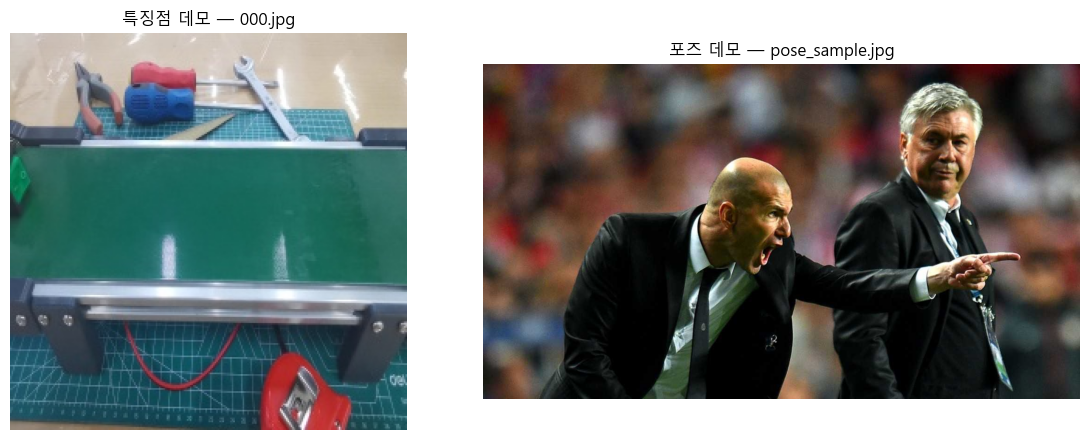

feature_demo: C:\MyCursorLab\08_Video AI 처리 및 분석\IPAD_Sample\R01\testing\frames\01\000.jpg
pose_demo   : output_keypoint\samples\pose_sample.jpg
ipad_frames : 24장


In [4]:
# ── Part 1: 데이터 준비 & 샘플 시각화 ──

CHECKER_PATH = SAMPLE_DIR / "checker_demo.png"
if not CHECKER_PATH.is_file():
    cv2.imencode(".png", make_checkerboard_pattern())[1].tofile(str(CHECKER_PATH))

ipad_frames = load_ipad_clip_frames()
pose_sample_path = ensure_pose_sample_image()

if ipad_frames:
    feature_demo_path = ipad_frames[0]
    print(f"[IPAD] 프레임 {len(ipad_frames)}장 | 예: {feature_demo_path.name}")
else:
    feature_demo_path = CHECKER_PATH
    print("[IPAD] 프레임 없음 — checker 패턴으로 Part 2~4 실행")

feature_demo_bgr = read_image_bgr(feature_demo_path)
pose_demo_bgr = read_image_bgr(pose_sample_path)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].imshow(bgr_to_rgb(feature_demo_bgr))
axes[0].set_title(f"특징점 데모 — {feature_demo_path.name}")
axes[0].axis("off")
axes[1].imshow(bgr_to_rgb(pose_demo_bgr))
axes[1].set_title(f"포즈 데모 — {pose_sample_path.name}")
axes[1].axis("off")
plt.tight_layout()
fig.savefig(FIG_DIR / "01_input_samples.png", dpi=130, bbox_inches="tight")
plt.show()

print(f"feature_demo: {feature_demo_path}")
print(f"pose_demo   : {pose_sample_path}")
print(f"ipad_frames : {len(ipad_frames)}장")


> **📖 Part 1 결과 해석 (초보자용)**
>
> | 출력 | 의미 |
> |------|------|
> | **왼쪽** | 설비 프레임 또는 체커보드 — **ORB/Harris** 특징점 실습용 |
> | **오른쪽** | 인물 샘플 — **포즈 17점** 실습용 |
> | **ipad_frames** | 0이면 zip 없음, Part 2~4는 합성 패턴으로 진행 |
>
> 💡 산업 영상은 사람이 없을 수 있습니다. 그때는 **특징점(ORB)** 이 설비 motion 분석의 핵심입니다.


## Part 2 — 특징점 검출 (Harris · Shi-Tomasi · ORB · RANSAC)

| 구성 | 설명 |
|------|------|
| **Harris heatmap** | 코너 응답 강도 시각화 |
| **Shi-Tomasi** | `goodFeaturesToTrack` 코너 |
| **ORB + Lowe ratio** | descriptor 매칭 |
| **RANSAC Homography** | inlier 비율 · reprojection error |

> 검출기 3종 비교 + 2프레임 기하 정합까지 수행합니다.


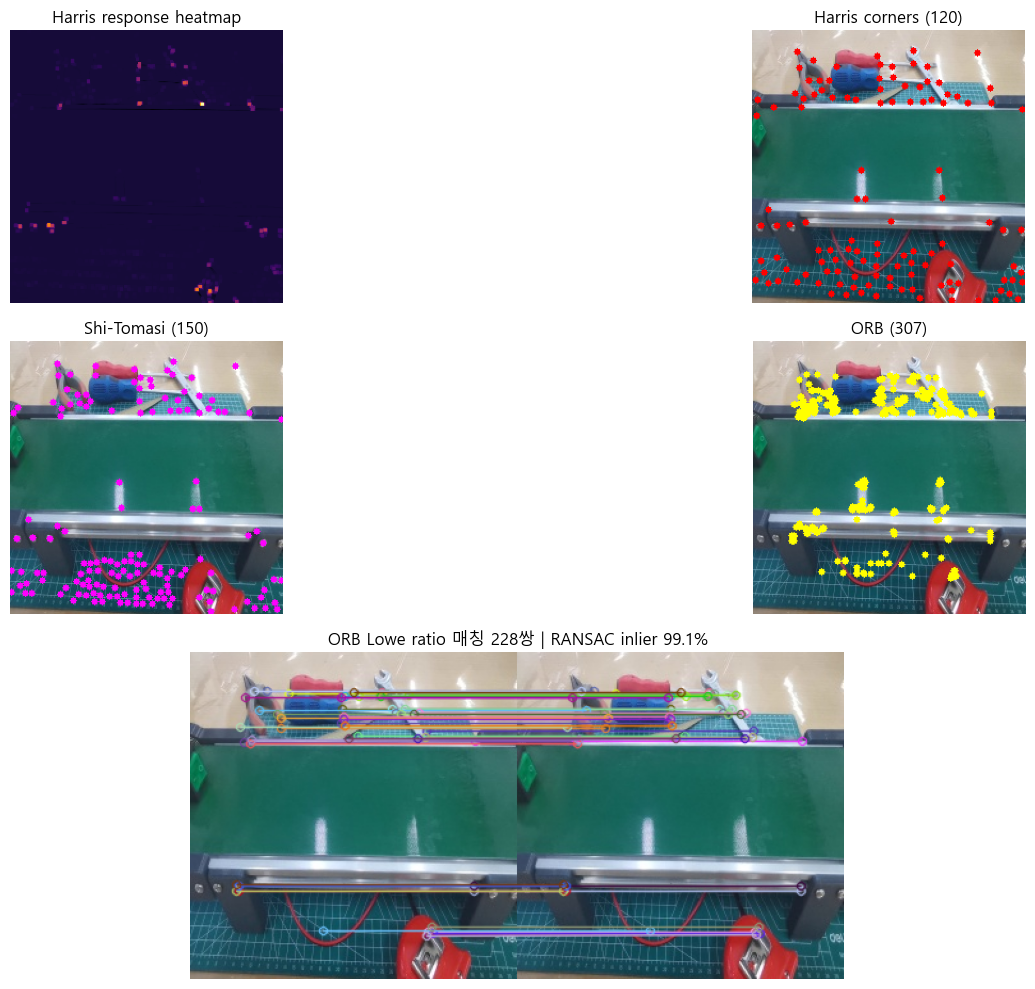

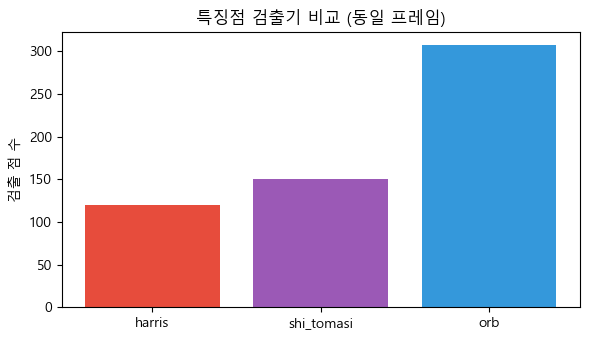

{'harris': 120, 'shi_tomasi': 150, 'orb': 307, 'orb_matches': 228, 'ransac_inliers': 226, 'ransac_inlier_ratio': 0.9912280701754386, 'ransac_reproj_error': 0.2801869511604309}


In [5]:
# ── Part 2: Harris · Shi-Tomasi · ORB · RANSAC ──
#
# 이 파트는 "인체 포즈"가 아니라, 설비/부품처럼 사람이 없어도 쓸 수 있는
# 특징점 기반 키포인트를 다룹니다.
#
# 핵심 흐름
# - 코너 응답(heatmap) 시각화: 어디가 특징점 후보인지 직관적으로 확인
# - 코너 검출 2종(Harris/ Shi-Tomasi): "점 좌표"를 얻는 가장 단순한 베이스라인
# - ORB: 특징점 + descriptor(지문) → 프레임 간 매칭/추적에 유리
# - RANSAC Homography: 매칭 중 "일관된" 쌍(inlier) 비율로 장면 유사도/변형 정도 추정


def compute_harris_response_map(image_bgr: np.ndarray) -> np.ndarray:
    """Harris corner response를 0~255 이미지로 정규화해 반환.

    반환값(resp)은 좌표를 직접 쓰기보다는 '어디가 코너 후보인지'를 heatmap으로
    보여주는 용도입니다.
    """
    # Harris는 그레이스케일 입력을 사용합니다.
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    # cornerHarris는 float32 입력이 필요합니다.
    harris = cv2.cornerHarris(np.float32(gray), blockSize=2, ksize=3, k=0.04)
    # 응답 맵을 조금 더 두껍게(dilate) 해서 시각화가 잘 보이게 합니다.
    harris = cv2.dilate(harris, None)
    # 시각화를 위해 0~255 범위로 정규화
    resp = cv2.normalize(harris, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    return resp


def detect_harris_corners(image_bgr: np.ndarray, max_corners: int = HARRIS_MAX_CORNERS) -> np.ndarray:
    resp = compute_harris_response_map(image_bgr)
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    pts = cv2.goodFeaturesToTrack(
        gray, maxCorners=max_corners, qualityLevel=0.01, minDistance=8,
    )
    if pts is None:
        harris = cv2.cornerHarris(np.float32(gray), 2, 3, 0.04)
        thresh = 0.01 * harris.max()
        ys, xs = np.where(harris > thresh)
        if len(xs) == 0:
            return np.zeros((0, 2), dtype=np.float32)
        scores = harris[ys, xs]
        order = np.argsort(-scores)[:max_corners]
        return np.stack([xs[order], ys[order]], axis=1).astype(np.float32)
    return pts.reshape(-1, 2).astype(np.float32)


def detect_shi_tomasi_corners(image_bgr: np.ndarray, max_corners: int = SHITOMASI_MAX_CORNERS) -> np.ndarray:
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    pts = cv2.goodFeaturesToTrack(
        gray,
        maxCorners=max_corners,
        qualityLevel=SHITOMASI_QUALITY,
        minDistance=SHITOMASI_MIN_DISTANCE,
        blockSize=7,
        useHarrisDetector=False,
    )
    if pts is None:
        return np.zeros((0, 2), dtype=np.float32)
    return pts.reshape(-1, 2).astype(np.float32)


def detect_orb_keypoints(image_bgr: np.ndarray, max_features: int = ORB_MAX_FEATURES):
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    orb = cv2.ORB_create(nfeatures=max_features)
    kps, desc = orb.detectAndCompute(gray, None)
    pts = np.array([kp.pt for kp in kps], dtype=np.float32) if kps else np.zeros((0, 2), dtype=np.float32)
    return pts, desc, kps


def match_orb_descriptors(desc1: np.ndarray | None, desc2: np.ndarray | None) -> list[cv2.DMatch]:
    if desc1 is None or desc2 is None or len(desc1) < 2 or len(desc2) < 2:
        return []
    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=False)
    pairs = bf.knnMatch(desc1, desc2, k=2)
    good = []
    for pair in pairs:
        if len(pair) < 2:
            continue
        m, n = pair
        if m.distance < ORB_MATCH_RATIO * n.distance:
            good.append(m)
    return good


def estimate_homography_ransac(
    kps1: list, kps2: list, matches: list[cv2.DMatch],
) -> dict:
    if len(matches) < 4:
        return {"inliers": 0, "inlier_ratio": 0.0, "reproj_error": None, "H": None}
    src = np.float32([kps1[m.queryIdx].pt for m in matches]).reshape(-1, 1, 2)
    dst = np.float32([kps2[m.trainIdx].pt for m in matches]).reshape(-1, 1, 2)
    H, mask = cv2.findHomography(src, dst, cv2.RANSAC, RANSAC_REPROJ_THRESH)
    inliers = int(mask.sum()) if mask is not None else 0
    ratio = inliers / max(len(matches), 1)
    reproj = None
    if H is not None and inliers >= 4:
        proj = cv2.perspectiveTransform(src, H)
        err = np.linalg.norm(proj - dst, axis=2)
        if mask is not None:
            reproj = float(err[mask.ravel() == 1].mean())
    return {"inliers": inliers, "inlier_ratio": float(ratio), "reproj_error": reproj, "H": H}


def compare_feature_detectors(image_bgr: np.ndarray) -> dict:
    harris = detect_harris_corners(image_bgr)
    shitomasi = detect_shi_tomasi_corners(image_bgr)
    orb_pts, _, _ = detect_orb_keypoints(image_bgr)
    return {
        "harris": int(len(harris)),
        "shi_tomasi": int(len(shitomasi)),
        "orb": int(len(orb_pts)),
    }


def draw_orb_matches(img1_bgr, img2_bgr, kps1, kps2, matches, max_draw: int = 50) -> np.ndarray:
    return cv2.drawMatches(
        img1_bgr, kps1, img2_bgr, kps2,
        matches[:max_draw], None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS,
    )


# --- 실행 ---
harris_resp = compute_harris_response_map(feature_demo_bgr)
harris_pts = detect_harris_corners(feature_demo_bgr)
shi_pts = detect_shi_tomasi_corners(feature_demo_bgr)
orb_pts, orb_desc, orb_kps = detect_orb_keypoints(feature_demo_bgr)
detector_counts = compare_feature_detectors(feature_demo_bgr)

if len(ipad_frames) >= 2:
    frame_b = read_image_bgr(ipad_frames[1])
    match_title = f"{ipad_frames[0].name} <-> {ipad_frames[1].name}"
else:
    frame_b = np.roll(feature_demo_bgr, shift=12, axis=1)
    match_title = "checker (shifted)"

pts_b, desc_b, kps_b = detect_orb_keypoints(frame_b)
good_matches = match_orb_descriptors(orb_desc, desc_b)
homography_stats = estimate_homography_ransac(orb_kps, kps_b, good_matches)

harris_vis = draw_feature_keypoints(feature_demo_bgr, harris_pts, color=(0, 0, 255))
shi_vis = draw_feature_keypoints(feature_demo_bgr, shi_pts, color=(255, 0, 255))
orb_vis = draw_feature_keypoints(feature_demo_bgr, orb_pts, color=(0, 255, 255))
match_vis = draw_orb_matches(feature_demo_bgr, frame_b, orb_kps, kps_b, good_matches)

fig = plt.figure(figsize=(15, 10))
gs = GridSpec(3, 2, figure=fig, height_ratios=[1, 1, 1.2])
ax0 = fig.add_subplot(gs[0, 0]); ax0.imshow(harris_resp, cmap="inferno"); ax0.set_title("Harris response heatmap"); ax0.axis("off")
ax1 = fig.add_subplot(gs[0, 1]); ax1.imshow(bgr_to_rgb(harris_vis)); ax1.set_title(f"Harris corners ({len(harris_pts)})"); ax1.axis("off")
ax2 = fig.add_subplot(gs[1, 0]); ax2.imshow(bgr_to_rgb(shi_vis)); ax2.set_title(f"Shi-Tomasi ({len(shi_pts)})"); ax2.axis("off")
ax3 = fig.add_subplot(gs[1, 1]); ax3.imshow(bgr_to_rgb(orb_vis)); ax3.set_title(f"ORB ({len(orb_pts)})"); ax3.axis("off")
ax4 = fig.add_subplot(gs[2, :]); ax4.imshow(bgr_to_rgb(match_vis)); ax4.set_title(
    f"ORB Lowe ratio 매칭 {len(good_matches)}쌍 | RANSAC inlier {homography_stats['inlier_ratio']:.1%}"
); ax4.axis("off")
plt.tight_layout()
fig.savefig(FIG_DIR / "02_feature_keypoints.png", dpi=130, bbox_inches="tight")
plt.show()

# 검출기 개수 비교 bar
fig2, axb = plt.subplots(figsize=(6, 3.5))
names = list(detector_counts.keys())
vals = [detector_counts[k] for k in names]
axb.bar(names, vals, color=["#e74c3c", "#9b59b6", "#3498db"])
axb.set_ylabel("검출 점 수")
axb.set_title("특징점 검출기 비교 (동일 프레임)")
plt.tight_layout()
fig2.savefig(FIG_DIR / "02b_detector_compare.png", dpi=130, bbox_inches="tight")
plt.show()

feature_stats = {
    **detector_counts,
    "orb_matches": int(len(good_matches)),
    "ransac_inliers": homography_stats["inliers"],
    "ransac_inlier_ratio": homography_stats["inlier_ratio"],
    "ransac_reproj_error": homography_stats["reproj_error"],
}
print(feature_stats)


> **📖 Part 2 결과 해석 (초보자용)**
>
> | 그래프 | 읽는 법 |
> |--------|---------|
> | **Harris heatmap** | 밝을수록 코너 응답이 강한 영역 |
> | **Shi-Tomasi** | Harris보다 안정적인 코너 후보 |
> | **ORB 매칭** | Lowe ratio로 좋은 쌍만 선택 |
> | **RANSAC inlier** | 90% 이상이면 두 프레임이 거의 같은 장면(카메라 시점 유사) |
> | **02b bar chart** | 동일 프레임에서 검출기별 점 개수 비교 |
>
> 💡 `ransac_reproj_error`가 작을수록 기하 정합 품질이 좋습니다. 설비가 크게 움직이면 inlier 비율이 떨어집니다.


## Part 3 — 인체 포즈 · 관절 각도 · IPAD 시도

| 구성 | 설명 |
|------|------|
| **Keypoint R-CNN** | COCO 17 관절 |
| **Joint angles** | 팔꿈치·무릎·어깨 각도 (인체공학) |
| **IPAD pose** | 설비 프레임에 인물 있으면 추가 검출 |


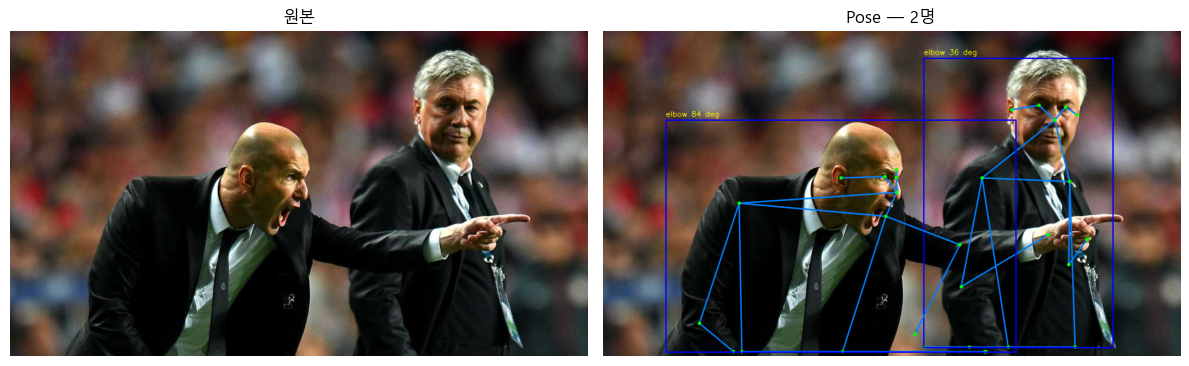

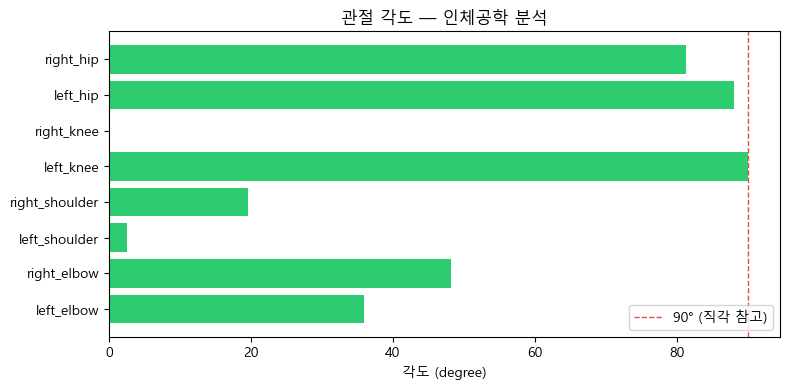

[IPAD] 인물 없음 — 설비 프레임은 특징점(Part 2·4) 분석이 적합
관절 각도: {'left_elbow': 35.9, 'right_elbow': 48.2, 'left_shoulder': 2.5, 'right_shoulder': 19.5, 'left_knee': 90.0, 'right_knee': 0.0, 'left_hip': 88.1, 'right_hip': 81.3}


In [6]:
# ── Part 3: Human Pose · 관절 각도 · IPAD 포즈 시도 ──

_pose_model = None


def get_pose_model():
    global _pose_model
    if _pose_model is None:
        weights = torchvision.models.detection.KeypointRCNN_ResNet50_FPN_Weights.COCO_V1
        _pose_model = keypointrcnn_resnet50_fpn(weights=weights)
        _pose_model.to(DEVICE).eval()
    return _pose_model


def detect_human_pose(image_bgr: np.ndarray, score_thresh: float = POSE_SCORE_THRESH) -> list[dict]:
    model = get_pose_model()
    rgb = bgr_to_rgb(image_bgr)
    tensor = TF.to_tensor(rgb).to(DEVICE)
    with torch.no_grad():
        outputs = model([tensor])[0]
    persons = []
    boxes = outputs.get("boxes", torch.zeros((0, 4))).cpu().numpy()
    keypoints = outputs.get("keypoints", torch.zeros((0, 17, 3))).cpu().numpy()
    scores = outputs.get("scores", torch.zeros(0)).cpu().numpy()
    for i in range(len(scores)):
        if float(scores[i]) < score_thresh:
            continue
        kpts = keypoints[i]
        person = {"bbox": boxes[i].tolist(), "score": float(scores[i]), "keypoints": []}
        for j, name in enumerate(COCO_KEYPOINT_NAMES):
            x, y, v = kpts[j]
            person["keypoints"].append({
                "name": name, "x": float(x), "y": float(y), "visibility": float(v),
            })
        persons.append(person)
    return persons


def compute_pose_angles(person: dict) -> dict[str, float]:
    kpt_xy = {k["name"]: np.array([k["x"], k["y"]], dtype=np.float32) for k in person["keypoints"]}
    kpt_vis = {k["name"]: k["visibility"] for k in person["keypoints"]}
    angles = {}
    for label, (i, j, k) in POSE_ANGLE_TRIPLETS.items():
        a_name, b_name, c_name = COCO_KEYPOINT_NAMES[i], COCO_KEYPOINT_NAMES[j], COCO_KEYPOINT_NAMES[k]
        if min(kpt_vis[a_name], kpt_vis[b_name], kpt_vis[c_name]) < POSE_KPT_VIS_THRESH:
            continue
        angles[label] = angle_between_points(kpt_xy[a_name], kpt_xy[b_name], kpt_xy[c_name])
    return angles


def enrich_person_with_angles(person: dict) -> dict:
    person = dict(person)
    person["joint_angles"] = compute_pose_angles(person)
    return person


def render_pose_overlay(image_bgr: np.ndarray, persons: list[dict], draw_angles: bool = True) -> np.ndarray:
    vis = image_bgr.copy()
    for person in persons:
        kpts = np.array([[k["x"], k["y"]] for k in person["keypoints"]], dtype=np.float32)
        vis_scores = np.array([k["visibility"] for k in person["keypoints"]], dtype=np.float32)
        vis = draw_pose_skeleton(vis, kpts, vis_scores)
        x1, y1, x2, y2 = [int(v) for v in person["bbox"]]
        cv2.rectangle(vis, (x1, y1), (x2, y2), (255, 0, 0), 2)
        if draw_angles and person.get("joint_angles"):
            elbow = person["joint_angles"].get("left_elbow") or person["joint_angles"].get("right_elbow")
            if elbow is not None:
                cv2.putText(vis, f"elbow {elbow:.0f} deg", (x1, max(20, y1 - 8)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 255, 255), 1, cv2.LINE_AA)
    return vis


def plot_pose_angles(angles: dict[str, float], save_path: Path) -> None:
    if not angles:
        return
    labels = list(angles.keys())
    values = [angles[k] for k in labels]
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.barh(labels, values, color="#2ecc71")
    ax.axvline(90, color="#e74c3c", linestyle="--", linewidth=1, label="90° (직각 참고)")
    ax.set_xlabel("각도 (degree)")
    ax.set_title("관절 각도 — 인체공학 분석")
    ax.legend(loc="lower right")
    plt.tight_layout()
    fig.savefig(save_path, dpi=130, bbox_inches="tight")
    plt.show()


pose_persons = [enrich_person_with_angles(p) for p in detect_human_pose(pose_demo_bgr)]
pose_vis = render_pose_overlay(pose_demo_bgr, pose_persons)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(bgr_to_rgb(pose_demo_bgr)); axes[0].set_title("원본"); axes[0].axis("off")
axes[1].imshow(bgr_to_rgb(pose_vis)); axes[1].set_title(f"Pose — {len(pose_persons)}명"); axes[1].axis("off")
plt.tight_layout()
fig.savefig(FIG_DIR / "03_human_pose.png", dpi=130, bbox_inches="tight")
plt.savefig(PRED_DIR / "pose_overlay.png", dpi=130, bbox_inches="tight")
plt.show()

pose_angles = pose_persons[0]["joint_angles"] if pose_persons else {}
plot_pose_angles(pose_angles, FIG_DIR / "03b_pose_angles.png")

ipad_pose_persons: list[dict] = []
if RUN_IPAD_POSE and ipad_frames:
    ipad_pose_bgr = read_image_bgr(ipad_frames[0])
    ipad_pose_persons = detect_human_pose(ipad_pose_bgr, score_thresh=0.5)
    if ipad_pose_persons:
        ipad_pose_vis = render_pose_overlay(ipad_pose_bgr, [enrich_person_with_angles(ipad_pose_persons[0])])
        cv2.imencode(".png", ipad_pose_vis)[1].tofile(str(PRED_DIR / "ipad_pose.png"))
        print(f"[IPAD] 포즈 검출 {len(ipad_pose_persons)}명 — predictions/ipad_pose.png 저장")
    else:
        print("[IPAD] 인물 없음 — 설비 프레임은 특징점(Part 2·4) 분석이 적합")

if pose_persons:
    print("관절 각도:", {k: round(v, 1) for k, v in pose_angles.items()})
else:
    print("[Pose] 인물 미검출 — POSE_SAMPLE_URL 또는 score_thresh 조정")


> **📖 Part 3 결과 해석 (초보자용)**
>
> - **초록 점** = COCO 17 관절 · **주황 선** = 스켈레톤
> - **03b_pose_angles** = 팔꿈치·무릎 등 관절 각도(도) — 90° 근처면 직각 자세
> - **elbow XX deg** 오버레이 = 대표 팔꿈치 각도
>
> IPAD에 인물이 없으면 0명이 정상입니다. 작업자 영상에서는 Part 5 **각도 변화**로 동작 안정성을 볼 수 있습니다.


## Part 4 — 적응형 추적 · motion z-score · 밀도맵 · manifest

| 단계 | 설명 |
|------|------|
| **Adaptive LK** | 추적 점 부족 시 ORB 재검출 |
| **Displacement z-score** | 04번 motion baseline과 동일 개념 |
| **Density heatmap** | 시퀀스 누적 키포인트 밀도 |
| **Manifest v1.1** | spike frame · z-score 포함 |


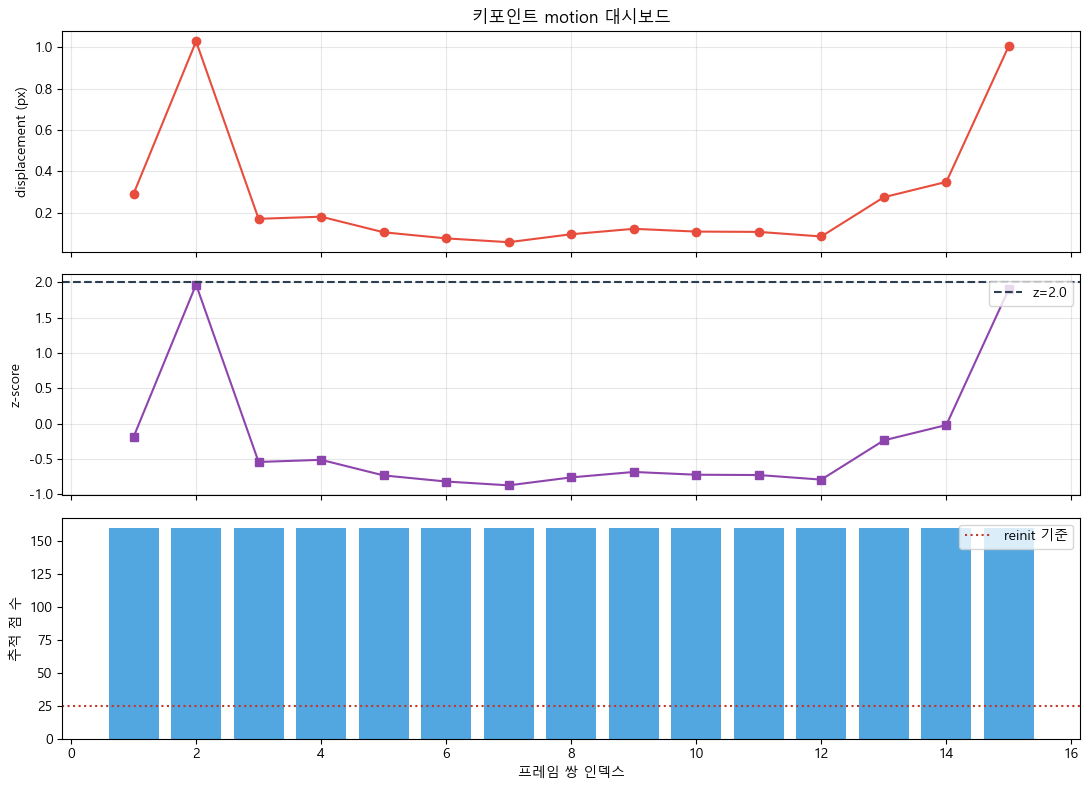

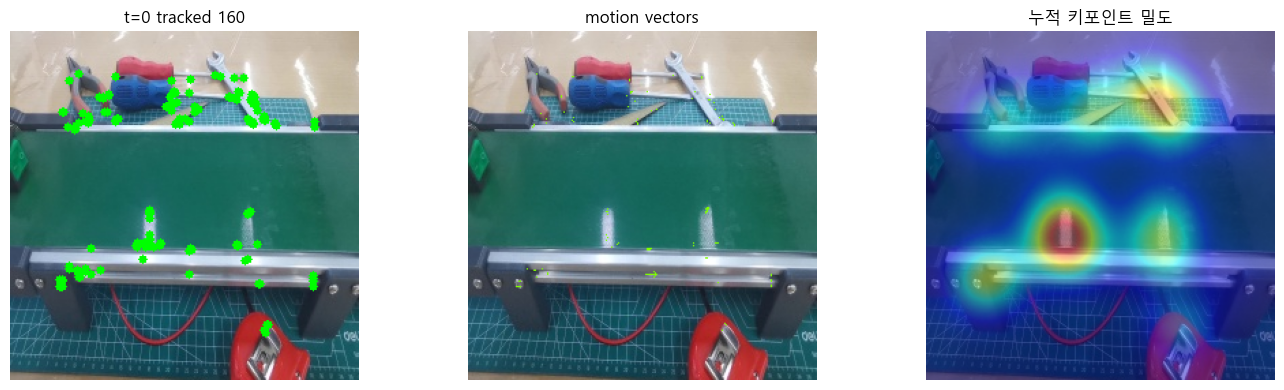

Manifest 저장: output_keypoint\keypoint_manifest.json
프레임 16장 | mean disp=0.27px | spikes=[]


In [7]:
# ── Part 4: 적응형 추적 · motion z-score · 밀도맵 · manifest ──

def track_keypoints_lk(
    prev_bgr: np.ndarray,
    next_bgr: np.ndarray,
    state: TrackingState | None = None,
    max_features: int = PIPELINE_ORB_FEATURES,
) -> tuple[np.ndarray, np.ndarray, TrackingState]:
    """Lucas-Kanade(LK) optical flow로 특징점들을 다음 프레임으로 이동(추적)합니다.

    입력
    - prev_bgr, next_bgr: 연속 프레임(색상)
    - state: 이전 프레임에서 유지하던 추적 상태(점 좌표)

    동작
    - 추적점이 너무 적으면(또는 state가 없으면) ORB로 새로 점을 재검출(re-init)
    - LK로 prev -> next 이동량을 추정

    출력
    - good_prev: 추적 성공한 prev 점들
    - good_next: 대응되는 next 점들
    - state: 다음 반복을 위한 최신 점 상태
    """
    # LK는 그레이스케일이 더 안정적입니다.
    prev_gray = cv2.cvtColor(prev_bgr, cv2.COLOR_BGR2GRAY)
    next_gray = cv2.cvtColor(next_bgr, cv2.COLOR_BGR2GRAY)

    # 추적점이 부족하면 ORB를 다시 뽑아 상태를 초기화합니다.
    if state is None or len(state.points) < MIN_TRACKED_POINTS:
        pts, desc, _ = detect_orb_keypoints(prev_bgr, max_features=max_features)
        state = TrackingState(points=pts, descriptors=desc)
    else:
        pts = state.points

    # 점이 0개면(예: 단색 프레임) 그냥 빈 결과를 반환합니다.
    if len(pts) == 0:
        return np.zeros((0, 2), dtype=np.float32), np.zeros((0, 2), dtype=np.float32), state

    # OpenCV LK: 입력 포맷은 (N,1,2)
    p1, st, _ = cv2.calcOpticalFlowPyrLK(
        prev_gray,
        next_gray,
        pts.reshape(-1, 1, 2),
        None,
        winSize=LK_WIN_SIZE,
        maxLevel=LK_MAX_LEVEL,
        criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 30, 0.01),
    )

    # st=1인 점만 유효(추적 성공)
    st = st.reshape(-1)
    good_prev = pts[st == 1]
    good_next = p1.reshape(-1, 2)[st == 1]

    # 다음 반복을 위해 next 점을 state로 보관
    state = TrackingState(points=good_next.astype(np.float32))
    return good_prev, good_next, state


def compute_keypoint_displacement(prev_pts: np.ndarray, next_pts: np.ndarray) -> float:
    if len(prev_pts) == 0:
        return 0.0
    return float(np.mean(np.linalg.norm(next_pts - prev_pts, axis=1)))


def compute_displacement_zscore(series: list[float], baseline_n: int = 5) -> list[float]:
    if not series:
        return []
    baseline = np.array(series[:baseline_n], dtype=np.float32)
    mu = float(baseline.mean()) if len(baseline) else 0.0
    sigma = float(baseline.std()) if len(baseline) > 1 else 1.0
    sigma = max(sigma, 1e-3)
    return [float((x - mu) / sigma) for x in series]


def detect_motion_spike_frames(zscores: list[float], threshold: float = DISPLACEMENT_Z_THRESHOLD) -> list[int]:
    return [i + 1 for i, z in enumerate(zscores) if z >= threshold]


def run_keypoint_pipeline(frame_paths: list[Path]) -> tuple[list[KeypointResult], list[float], list[float]]:
    results: list[KeypointResult] = []
    displacements: list[float] = []
    if not frame_paths:
        return results, displacements, []

    prev_img = read_image_bgr(frame_paths[0])
    pts0, _, _ = detect_orb_keypoints(prev_img, max_features=PIPELINE_ORB_FEATURES)
    state = TrackingState(points=pts0)
    all_tracked: list[np.ndarray] = [pts0]

    results.append(KeypointResult(
        image_path=str(frame_paths[0]), method="orb",
        feature_points=[[float(x), float(y), 1.0] for x, y in pts0],
        meta={"frame_index": 0, "tracked_points": int(len(pts0))},
    ))

    for idx in range(1, len(frame_paths)):
        curr_img = read_image_bgr(frame_paths[idx])
        prev_pts, next_pts, state = track_keypoints_lk(prev_img, curr_img, state=state)
        disp = compute_keypoint_displacement(prev_pts, next_pts)
        displacements.append(disp)
        all_tracked.append(next_pts)
        results.append(KeypointResult(
            image_path=str(frame_paths[idx]), method="orb_lk_adaptive",
            feature_points=[[float(x), float(y), 1.0] for x, y in next_pts],
            displacement=disp,
            meta={"frame_index": idx, "tracked_points": int(len(next_pts)), "reinit": len(prev_pts) < MIN_TRACKED_POINTS},
        ))
        prev_img = curr_img

    zscores = compute_displacement_zscore(displacements)
    for i, z in enumerate(zscores, start=1):
        results[i].motion_z = z

    return results, displacements, zscores


def plot_motion_dashboard(
    displacements: list[float],
    zscores: list[float],
    tracked_counts: list[int],
    save_path: Path,
) -> None:
    if not displacements:
        return
    x = np.arange(1, len(displacements) + 1)
    fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)

    axes[0].plot(x, displacements, marker="o", color="#e74c3c")
    axes[0].set_ylabel("displacement (px)")
    axes[0].set_title("키포인트 motion 대시보드")
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(x, zscores, marker="s", color="#8e44ad")
    axes[1].axhline(DISPLACEMENT_Z_THRESHOLD, color="#2c3e50", linestyle="--", label=f"z={DISPLACEMENT_Z_THRESHOLD}")
    axes[1].set_ylabel("z-score")
    axes[1].legend(loc="upper right")
    axes[1].grid(True, alpha=0.3)

    axes[2].bar(x, tracked_counts, color="#3498db", alpha=0.85)
    axes[2].axhline(MIN_TRACKED_POINTS, color="#c0392b", linestyle=":", label="reinit 기준")
    axes[2].set_xlabel("프레임 쌍 인덱스")
    axes[2].set_ylabel("추적 점 수")
    axes[2].legend(loc="upper right")

    plt.tight_layout()
    fig.savefig(save_path, dpi=130, bbox_inches="tight")
    plt.show()


def export_keypoint_manifest(
    results: list[KeypointResult],
    displacements: list[float],
    zscores: list[float],
    pose_results: list[KeypointResult] | None = None,
    extra: dict | None = None,
) -> Path:
    spike_frames = detect_motion_spike_frames(zscores)
    payload = {
        "version": "1.1",
        "dataset": "IPAD_frames" if ipad_frames else "synthetic",
        "engine": "opencv_orb_lk + torchvision_keypointrcnn",
        "num_frames": len(results),
        "displacement_series": displacements,
        "displacement_zscore": zscores,
        "mean_displacement": float(np.mean(displacements)) if displacements else 0.0,
        "motion_spike_frames": spike_frames,
        "motion_z_threshold": DISPLACEMENT_Z_THRESHOLD,
        "frames": [
            {
                "image_path": r.image_path,
                "method": r.method,
                "displacement": r.displacement,
                "motion_z": r.motion_z,
                "num_feature_points": len(r.feature_points),
                "feature_points": r.feature_points[:80],
                "meta": r.meta,
            }
            for r in results
        ],
    }
    if pose_results:
        payload["pose_samples"] = [
            {
                "image_path": r.image_path,
                "pose_persons": r.pose_persons,
            }
            for r in pose_results
        ]
    if extra:
        payload.update(extra)
    MANIFEST_PATH.write_text(json.dumps(payload, ensure_ascii=False, indent=2), encoding="utf-8")
    return MANIFEST_PATH


# --- 파이프라인 실행 ---
if ipad_frames:
    pipeline_frames = ipad_frames[:min(16, len(ipad_frames))]
else:
    pipeline_frames = []
    base = read_image_bgr(CHECKER_PATH)
    for i in range(10):
        p = PRED_DIR / f"checker_seq_{i:02d}.png"
        shifted = np.roll(base, shift=5 * (i + 1), axis=1)
        cv2.imencode(".png", shifted)[1].tofile(str(p))
        pipeline_frames.append(p)

kp_results, disp_series, z_series = run_keypoint_pipeline(pipeline_frames)
tracked_counts = [r.meta.get("tracked_points", 0) for r in kp_results[1:]]
plot_motion_dashboard(disp_series, z_series, tracked_counts, FIG_DIR / "04_motion_dashboard.png")

# 밀도 히트맵 + 벡터 시각화
if len(pipeline_frames) >= 2:
    img_a = read_image_bgr(pipeline_frames[0])
    img_b = read_image_bgr(pipeline_frames[1])
    p_prev, p_next, _ = track_keypoints_lk(img_a, img_b)
    vector_vis = draw_motion_vectors(img_b, p_prev, p_next, step=2)

    all_pts = []
    for fp in pipeline_frames:
        pts, _, _ = detect_orb_keypoints(read_image_bgr(fp), max_features=120)
        all_pts.append(pts)
    density = build_keypoint_density_map(all_pts, img_a.shape[:2])
    density_rgb = cv2.applyColorMap((density * 255).astype(np.uint8), cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(img_a, 0.55, density_rgb, 0.45, 0)

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    axes[0].imshow(bgr_to_rgb(draw_feature_keypoints(img_a, p_prev, color=(0, 255, 0))))
    axes[0].set_title(f"t=0 tracked {len(p_prev)}"); axes[0].axis("off")
    axes[1].imshow(bgr_to_rgb(vector_vis)); axes[1].set_title("motion vectors"); axes[1].axis("off")
    axes[2].imshow(bgr_to_rgb(overlay)); axes[2].set_title("누적 키포인트 밀도"); axes[2].axis("off")
    plt.tight_layout()
    fig.savefig(FIG_DIR / "04_tracking_density.png", dpi=130, bbox_inches="tight")
    plt.show()

pose_manifest_entries = [
    KeypointResult(image_path=str(pose_sample_path), method="keypointrcnn", pose_persons=pose_persons),
]
if ipad_pose_persons:
    pose_manifest_entries.append(
        KeypointResult(image_path=str(ipad_frames[0]), method="keypointrcnn_ipad", pose_persons=ipad_pose_persons)
    )

manifest_path = export_keypoint_manifest(
    kp_results, disp_series, z_series,
    pose_results=pose_manifest_entries,
    extra={"feature_stats": feature_stats, "pose_angles_sample": pose_angles},
)
spikes = detect_motion_spike_frames(z_series)
print(f"Manifest 저장: {manifest_path}")
print(f"프레임 {len(kp_results)}장 | mean disp={np.mean(disp_series) if disp_series else 0:.2f}px | spikes={spikes}")


> **📖 Part 4 결과 해석 (초보자용)**
>
> ### 저장된 산출물
> | 파일/폴더 | 설명 |
> |-----------|------|
> | `output_keypoint/keypoint_manifest.json` | 프레임별 특징점 수·displacement·포즈 샘플 |
> | `figures/04_motion_dashboard.png` | displacement · z-score · 추적 점 수 3단 |
> | `figures/04_tracking_density.png` | motion vector + 누적 밀도맵 |
> | `motion_spike_frames` (JSON) | z-score가 경고선 넘은 프레임 인덱스 |
>
> ### 대시보드 읽는 법
> - **z-score**가 `DISPLACEMENT_Z_THRESHOLD`(기본 2.0) 위 → 04번 motion 이상 후보
> - **추적 점 수**가 `MIN_TRACKED_POINTS` 아래로 떨어지면 ORB 재검출(reinit)
> - **밀도맵** 밝은 영역 = 프레임 전체에서 키포인트가 자주 나타난 위치(설비 고정부 후보)
>
> 💡 `keypoint_manifest.json`은 **08 통합 manifest**의 입력 중 하나입니다.


## Part 5 — 고급: 프레임 간 포즈 안정성 · 요약 지표

연속 프레임에서 **어깨 중심 이동**과 **관절 각도 변화**를 측정합니다.

| 지표 | 설명 |
|------|------|
| **shoulder_center_disp** | 좌·우 어깨 중점의 프레임 간 이동 |
| **angle_delta** | 관절 각도 변화량 (안정성) |

> IPAD 설비 프레임에 인물이 없으면 **포즈 샘플 합성 시퀀스**(미세 이동·회전)로 시간축 데모를 자동 생성합니다.


[Part 5] 연속 인물 프레임 부족 → pose 샘플 합성 시퀀스로 시간축 데모


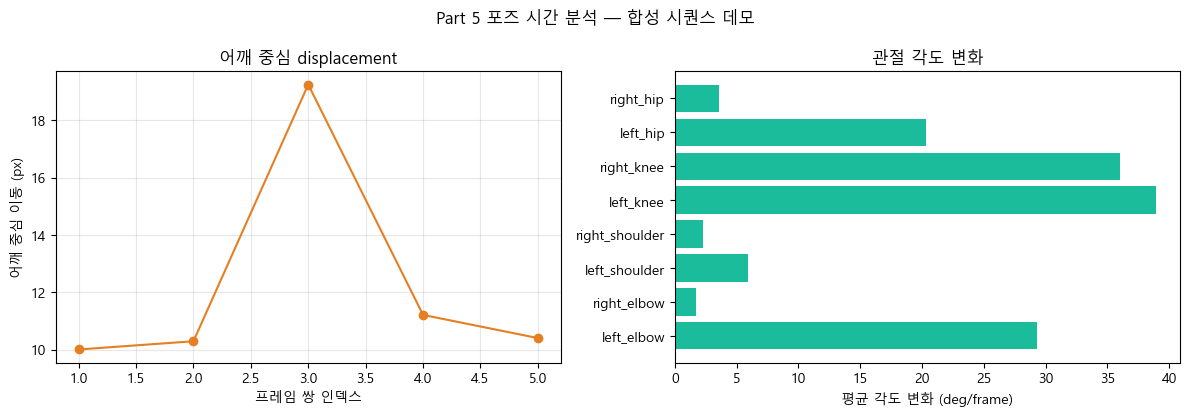

포즈 시간 분석: {'frames_with_person': 6, 'shoulder_center_displacement': [10.000935432754407, 10.28801369299958, 19.25211464061035, 11.20799538838608, 10.398958346969271], 'mean_shoulder_disp': 12.229603500343938, 'mean_angle_delta': {'left_elbow': 29.303774716168505, 'right_elbow': 1.7459503196737303, 'left_shoulder': 5.884700234351969, 'right_shoulder': 2.2634668760976915, 'left_knee': 38.92211455786502, 'right_knee': 35.99941384948819, 'left_hip': 20.341813280438963, 'right_hip': 3.581420243382925}, 'last_joint_angles': {'left_elbow': 15.350455827683735, 'right_elbow': 48.236071927746316, 'left_shoulder': 1.7301034191700861, 'right_shoulder': 19.265762638587866, 'left_knee': 14.610621018320133, 'right_knee': 0.000512379434231137, 'left_hip': 7.531250412356209, 'right_hip': 78.44005812067076}}
분석 프레임: 6장 (synthetic)


In [8]:
# ── Part 5: 포즈 시간 안정성 (인물 검출 시) ──

def shoulder_center(person: dict) -> np.ndarray | None:
    kpt = {k["name"]: k for k in person["keypoints"]}
    need = ("left_shoulder", "right_shoulder")
    if any(kpt[n]["visibility"] < POSE_KPT_VIS_THRESH for n in need):
        return None
    ls = np.array([kpt["left_shoulder"]["x"], kpt["left_shoulder"]["y"]])
    rs = np.array([kpt["right_shoulder"]["x"], kpt["right_shoulder"]["y"]])
    return (ls + rs) / 2.0


def build_pose_demo_sequence(base_path: Path, n_frames: int = 6) -> list[Path]:
    """포즈 샘플을 미세 이동·회전해 시간축 데모 시퀀스 생성 (IPAD에 인물 없을 때)."""
    base = read_image_bgr(base_path)
    h, w = base.shape[:2]
    cx, cy = w / 2.0, h / 2.0
    seq_dir = SAMPLE_DIR / "pose_seq"
    seq_dir.mkdir(parents=True, exist_ok=True)
    paths: list[Path] = []
    for i in range(n_frames):
        angle = (i - n_frames // 2) * 1.2
        scale = 1.0 + i * 0.012
        dx, dy = i * 6, int(np.sin(i * 0.8) * 4)
        M = cv2.getRotationMatrix2D((cx, cy), angle, scale)
        M[0, 2] += dx
        M[1, 2] += dy
        warped = cv2.warpAffine(base, M, (w, h), borderMode=cv2.BORDER_REPLICATE)
        out = seq_dir / f"pose_seq_{i:02d}.jpg"
        cv2.imencode(".jpg", warped)[1].tofile(str(out))
        paths.append(out)
    return paths


def collect_pose_temporal_frames(max_frames: int = 6) -> tuple[list[Path], str]:
    """시간축 포즈 분석에 쓸 프레임들을 모읍니다.

    포즈 "변화"(각도 델타, 이동량)는 최소 2프레임이 있어야 계산됩니다.

    우선순위
    - (가능하면) 실제 프레임에서 인물이 검출되는 연속 프레임을 최대 max_frames까지 수집
    - 그렇지 않으면: 포즈 샘플 이미지를 미세 이동/회전한 합성 시퀀스를 생성해 데모

    반환
    - paths: 분석에 사용할 프레임 경로 리스트
    - source: 'real' 또는 'synthetic' (그래프 제목/로그에 표시)
    """
    # 실제 프레임 후보: 포즈 샘플 1장 + (있다면) IPAD 프레임 일부
    candidates = [pose_sample_path] + (ipad_frames[:10] if ipad_frames else [])

    person_paths: list[Path] = []
    for fp in candidates:
        img = read_image_bgr(fp)
        # 빠른 필터: 프레임에 사람이 잡히는지만 확인
        if detect_human_pose(img, score_thresh=0.5):
            person_paths.append(fp)
        if len(person_paths) >= max_frames:
            break

    # 2프레임 이상이면 델타 계산이 가능
    if len(person_paths) >= 2:
        return person_paths[:max_frames], "real"

    # 실제 인물 프레임이 부족한 경우(예: IPAD 설비 영상)는 합성 시퀀스로 데모
    print("[Part 5] 연속 인물 프레임 부족 → pose 샘플 합성 시퀀스로 시간축 데모")
    return build_pose_demo_sequence(pose_sample_path, n_frames=max_frames), "synthetic"


def analyze_pose_temporal_stability(frame_paths: list[Path]) -> dict:
    """연속 프레임 포즈 — 어깨 중심 이동·각도 변화."""
    centers: list[np.ndarray] = []
    angle_series: list[dict] = []
    for fp in frame_paths:
        img = read_image_bgr(fp)
        persons = detect_human_pose(img, score_thresh=0.5)
        if not persons:
            continue
        p = enrich_person_with_angles(persons[0])
        c = shoulder_center(p)
        if c is not None:
            centers.append(c)
        angle_series.append(p.get("joint_angles", {}))

    center_disp = [
        float(np.linalg.norm(centers[i] - centers[i - 1]))
        for i in range(1, len(centers))
    ]

    angle_deltas: dict[str, list[float]] = {}
    for i in range(1, len(angle_series)):
        for k in angle_series[i]:
            if k in angle_series[i - 1]:
                angle_deltas.setdefault(k, []).append(abs(angle_series[i][k] - angle_series[i - 1][k]))

    return {
        "frames_with_person": len(angle_series),
        "shoulder_center_displacement": center_disp,
        "mean_shoulder_disp": float(np.mean(center_disp)) if center_disp else None,
        "mean_angle_delta": {k: float(np.mean(v)) for k, v in angle_deltas.items()},
        "last_joint_angles": angle_series[-1] if angle_series else {},
    }


def plot_pose_temporal_results(pose_temporal: dict, source: str) -> None:
    disp = pose_temporal["shoulder_center_displacement"]
    angle_delta = pose_temporal["mean_angle_delta"]
    static_angles = pose_temporal.get("last_joint_angles", {})

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

    if disp:
        axes[0].plot(range(1, len(disp) + 1), disp, "o-", color="#e67e22")
        axes[0].set_xlabel("프레임 쌍 인덱스")
        axes[0].set_ylabel("어깨 중심 이동 (px)")
        axes[0].set_title("어깨 중심 displacement")
        axes[0].grid(True, alpha=0.3)
    else:
        axes[0].text(0.5, 0.5, "이동 데이터 없음\n(인물 1프레임만 검출)", ha="center", va="center")
        axes[0].set_axis_off()

    if angle_delta:
        labels = list(angle_delta.keys())
        vals = [angle_delta[k] for k in labels]
        axes[1].barh(labels, vals, color="#1abc9c")
        axes[1].set_xlabel("평균 각도 변화 (deg/frame)")
        axes[1].set_title("관절 각도 변화")
    elif static_angles:
        labels = list(static_angles.keys())
        vals = [static_angles[k] for k in labels]
        axes[1].barh(labels, vals, color="#3498db")
        axes[1].axvline(90, color="#e74c3c", linestyle="--", linewidth=1)
        axes[1].set_xlabel("각도 (degree)")
        axes[1].set_title("관절 각도 스냅샷 (시간 변화 없음)")
    else:
        axes[1].text(0.5, 0.5, "포즈 각도 데이터 없음", ha="center", va="center")
        axes[1].set_axis_off()

    src_label = "실제 프레임" if source == "real" else "합성 시퀀스 데모"
    fig.suptitle(f"Part 5 포즈 시간 분석 — {src_label}", fontsize=12)
    plt.tight_layout()
    fig.savefig(FIG_DIR / "05_pose_temporal.png", dpi=130, bbox_inches="tight")
    plt.show()


pose_seq_paths, pose_seq_source = collect_pose_temporal_frames(max_frames=6)
pose_temporal = analyze_pose_temporal_stability(pose_seq_paths)

if pose_temporal["frames_with_person"]:
    plot_pose_temporal_results(pose_temporal, pose_seq_source)
    print("포즈 시간 분석:", pose_temporal)
    print(f"분석 프레임: {len(pose_seq_paths)}장 ({pose_seq_source})")
else:
    print("[Part 5] 인물 미검출 — 설비 영상은 Part 4 displacement/z-score 활용")


---

### 실습 요약

- **Part 1** — IPAD / 합성 패턴 · 포즈 샘플
- **Part 2** — Harris heatmap · Shi-Tomasi · ORB · RANSAC homography
- **Part 3** — Keypoint R-CNN · 관절 각도 · IPAD 포즈 시도
- **Part 4** — 적응형 LK · z-score · 밀도맵 · manifest v1.1
- **Part 5** — 포즈 시간 안정성 (인물 있을 때)

## 생성된 파일

| 파일 | 내용 |
|------|------|
| `figures/02_feature_keypoints.png` | Harris/ORB/매칭 3행 패널 |
| `figures/02b_detector_compare.png` | 검출기 bar 비교 |
| `figures/03b_pose_angles.png` | 관절 각도 |
| `figures/04_motion_dashboard.png` | displacement · z-score · 추적 수 |
| `figures/04_tracking_density.png` | 벡터 + 밀도 오버레이 |
| `figures/05_pose_temporal.png` | 포즈 각도 변화 (인물 있을 때) |
| `keypoint_manifest.json` | spike frame · z-score 포함 |

> **다음 단계:** `08` 통합 manifest
